# LLM Evaluation: LLM Jury

In this tutorial, we evaluate whether customer support answers match a professional corporate tone of voice.

Unlike factual evaluation, tone evaluation is subjective. Different evaluators may disagree about whether an answer sounds professional, too casual, too robotic, or inappropriate for customer communication.

To make evaluation more robust, we use an **LLM jury**:
- multiple LLM judges independently review the same answer
- each judge assigns a `pass` or `failed` label
- the final decision is selected using majority vote

This setup is useful for subjective evaluation tasks where a single judge may be unstable or inconsistent.

## 1. Setup

We use `pandas` to store assistant answers and jury decisions in a single table.

In [1]:
import json
import os
from collections import Counter
from typing import Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

## 2. Dataset

The dataset contains customer support answers with different communication styles.

Some answers follow a professional corporate tone, while others are too casual, rude, robotic, or overly informal.

In [2]:
customer_queries = [
    "Can I return an item if it does not fit?",
    "Where is my order?",
    "Can I cancel my subscription?",
    "Why was my payment declined?",
    "Can you help me track my package?",
    "How do I reset my password?",
    "My package arrived damaged.",
    "Do you offer refunds?",
]

assistant_answers = [
    "Yes, most items can be returned within the allowed return window if they are unused and in original condition.",
    "No idea honestly, shipping delays happen all the time. Just wait a bit longer.",
    "You can usually cancel your subscription from your account settings or by contacting support.",
    "Your payment may have been declined by your bank or payment provider. Please try another payment method or contact your bank for more details.",
    "Yep! Just click the tracking link we sent you.",
    "To reset your password, use the 'Forgot password' option on the sign-in page and follow the instructions sent to your email.",
    "That sucks. Send us a picture and we'll figure something out.",
    "Refund eligibility depends on the store policy and the condition of the item. Please review the refund policy or contact support.",
]

df = pd.DataFrame({
    "customer_query": customer_queries,
    "assistant_answer": assistant_answers,
})

df

,customer_query,assistant_answer
0,Can I return an item if it does not fit?,"Yes, most items can be returned within the all..."
1,Where is my order?,"No idea honestly, shipping delays happen all t..."
2,Can I cancel my subscription?,You can usually cancel your subscription from ...
3,Why was my payment declined?,Your payment may have been declined by your ba...
4,Can you help me track my package?,Yep! Just click the tracking link we sent you.
5,How do I reset my password?,"To reset your password, use the 'Forgot passwo..."
6,My package arrived damaged.,That sucks. Send us a picture and we'll figure...
7,Do you offer refunds?,Refund eligibility depends on the store policy...


## 3. Jury rubric

Each judge evaluates whether the answer matches a professional customer support tone.

In [3]:
JUDGE_PROMPT = """You are evaluating answers from an e-commerce customer support assistant.
Label the answer as pass or failed. Use this criteria:
PASS if the answer:
- is clear, empathetic and human-like
- is professional and useful for a customer
FAILED if the answer:
- is hard to understand, too formal or overly casual
- is too vague to be useful

Return only valid JSON with this schema:
{
  "label": "pass" | "failed",
  "reasoning": "short explanation"
}
"""

def build_judge_input(row: pd.Series) -> str:
    return f"""Customer question:
{row["customer_query"]}

Assistant answer:
{row["assistant_answer"]}
"""

## 4. Define the jury

We use three independent LLM judges.

Each judge reviews the same answer separately.

In [4]:
judge_models = [
    "gpt-5.5",
    "gpt-4.1",
    "gpt-4o",
]

judge_models

['gpt-5.5', 'gpt-4.1', 'gpt-4o']

## 5. Run the jury

Each judge predicts a label independently.

If the OpenAI API key is unavailable, the notebook uses demo outputs.

In [5]:
def parse_judge_output(text: str) -> Dict[str, Any]:
    try:
        result = json.loads(text)
    except json.JSONDecodeError:
        return {
            "label": "failed",
            "reasoning": f"Invalid JSON returned by judge: {text[:200]}",
        }

    if result.get("label") not in ["pass", "failed"]:
        return {
            "label": "failed",
            "reasoning": f"Unexpected label returned by judge: {result}",
        }

    return {
        "label": result["label"],
        "reasoning": result.get("reasoning", ""),
    }


In [6]:
def call_judge(row: pd.Series, model: str) -> Dict[str, Any]:
    from openai import OpenAI

    client = OpenAI()

    try:
        response = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": JUDGE_PROMPT},
                {"role": "user", "content": build_judge_input(row)},
            ],
        )

        return parse_judge_output(response.output_text)

    except Exception as e:
        return {
            "label": "failed",
            "reasoning": f"Judge call failed: {type(e).__name__}: {e}",
        }



In [7]:
demo_outputs = {
    0: {
        "gpt-5.5": {"label": "pass", "reasoning": "Professional and clear."},
        "gpt-4.1": {"label": "pass", "reasoning": "Appropriate corporate tone."},
        "gpt-4o": {"label": "pass", "reasoning": "Helpful and respectful."},
    },
    1: {
        "gpt-5.5": {"label": "failed", "reasoning": "Dismissive tone."},
        "gpt-4.1": {"label": "failed", "reasoning": "Too casual and unhelpful."},
        "gpt-4o": {"label": "failed", "reasoning": "Not appropriate for customer support."},
    },
    2: {
        "gpt-5.5": {"label": "pass", "reasoning": "Professional and helpful."},
        "gpt-4.1": {"label": "pass", "reasoning": "Clear customer guidance."},
        "gpt-4o": {"label": "pass", "reasoning": "Appropriate support tone."},
    },
    3: {
        "gpt-5.5": {"label": "pass", "reasoning": "Professional explanation."},
        "gpt-4.1": {"label": "pass", "reasoning": "Clear and respectful."},
        "gpt-4o": {"label": "pass", "reasoning": "Appropriate customer tone."},
    },
    4: {
        "gpt-5.5": {"label": "failed", "reasoning": "Too casual."},
        "gpt-4.1": {"label": "pass", "reasoning": "Friendly but acceptable."},
        "gpt-4o": {"label": "failed", "reasoning": "Informal tone."},
    },
    5: {
        "gpt-5.5": {"label": "pass", "reasoning": "Professional instructions."},
        "gpt-4.1": {"label": "pass", "reasoning": "Clear and appropriate."},
        "gpt-4o": {"label": "pass", "reasoning": "Good customer communication."},
    },
    6: {
        "gpt-5.5": {"label": "failed", "reasoning": "Too casual and vague."},
        "gpt-4.1": {"label": "failed", "reasoning": "Unprofessional phrasing."},
        "gpt-4o": {"label": "pass", "reasoning": "Empathetic and actionable."},
    },
    7: {
        "gpt-5.5": {"label": "pass", "reasoning": "Professional and safe."},
        "gpt-4.1": {"label": "pass", "reasoning": "Clear and appropriate."},
        "gpt-4o": {"label": "pass", "reasoning": "Professional tone."},
    },
}

def run_demo_judge(row: pd.Series, model: str):
    return demo_outputs[row.name][model]


In [8]:
use_api = bool(os.getenv("OPENAI_API_KEY"))

for model in judge_models:
    labels = []
    reasonings = []

    for _, row in df.iterrows():
        if use_api:
            result = call_judge(row, model)
        else:
            result = run_demo_judge(row, model)

        labels.append(result["label"])
        reasonings.append(result["reasoning"])

    safe_name = model.replace(".", "_").replace("-", "_")

    df[f"{safe_name}_label"] = labels
    df[f"{safe_name}_reasoning"] = reasonings

df

,customer_query,assistant_answer,gpt_5_5_label,gpt_5_5_reasoning,gpt_4_1_label,gpt_4_1_reasoning,gpt_4o_label,gpt_4o_reasoning
0,Can I return an item if it does not fit?,"Yes, most items can be returned within the all...",pass,"Clear, professional, and directly answers the ...",pass,"The answer is clear, direct, and provides usef...",pass,"The answer is clear, professional, and provide..."
1,Where is my order?,"No idea honestly, shipping delays happen all t...",failed,"The answer is dismissive, overly casual, and d...",failed,"The answer is unprofessional, lacks empathy, p...",failed,"The response is unprofessional, lacks clarity ..."
2,Can I cancel my subscription?,You can usually cancel your subscription from ...,pass,"Clear, professional, and gives the customer us...",failed,The answer is too vague and does not provide s...,failed,The answer is too vague and doesn't provide sp...
3,Why was my payment declined?,Your payment may have been declined by your ba...,pass,"The answer is clear, professional, and provide...",pass,"The answer is clear, professional, and provide...",failed,The answer lacks empathy and does not offer en...
4,Can you help me track my package?,Yep! Just click the tracking link we sent you.,failed,"The response is too brief and casual, and it d...",failed,"The answer is too casual ('Yep!'), lacks empat...",failed,The answer is too vague and lacks empathy. It ...
5,How do I reset my password?,"To reset your password, use the 'Forgot passwo...",pass,"Clear, professional, and provides the key step...",pass,"The response is clear, concise, and directly a...",pass,"The answer is clear, professional, and provide..."
6,My package arrived damaged.,That sucks. Send us a picture and we'll figure...,failed,"The response is overly casual and vague, and i...",failed,The response is overly casual and lacks profes...,failed,"The response is too casual with 'That sucks,' ..."
7,Do you offer refunds?,Refund eligibility depends on the store policy...,pass,"The answer is clear and professional, and it g...",pass,"The answer is clear, professional, and directs...",failed,The answer is too vague and not empathetic. It...


## 6. Majority vote

The final jury decision is selected using majority voting across all judges.

In [9]:
label_columns = [
    "gpt_5_5_label",
    "gpt_4_1_label",
    "gpt_4o_label",
]

def majority_vote(labels):
    counts = Counter(labels)
    return counts.most_common(1)[0][0]

def agreement_strength(labels):
    counts = Counter(labels)
    top_count = counts.most_common(1)[0][1]
    return f"{top_count}/3"

df["jury_label"] = df[label_columns].apply(
    lambda row: majority_vote(row.tolist()),
    axis=1,
)

df["jury_agreement"] = df[label_columns].apply(
    lambda row: agreement_strength(row.tolist()),
    axis=1,
)

df[[
    "assistant_answer",
    "gpt_5_5_label",
    "gpt_4_1_label",
    "gpt_4o_label",
    "jury_label",
    "jury_agreement",
]]

,assistant_answer,gpt_5_5_label,gpt_4_1_label,gpt_4o_label,jury_label,jury_agreement
0,"Yes, most items can be returned within the all...",pass,pass,pass,pass,3/3
1,"No idea honestly, shipping delays happen all t...",failed,failed,failed,failed,3/3
2,You can usually cancel your subscription from ...,pass,failed,failed,failed,2/3
3,Your payment may have been declined by your ba...,pass,pass,failed,pass,2/3
4,Yep! Just click the tracking link we sent you.,failed,failed,failed,failed,3/3
5,"To reset your password, use the 'Forgot passwo...",pass,pass,pass,pass,3/3
6,That sucks. Send us a picture and we'll figure...,failed,failed,failed,failed,3/3
7,Refund eligibility depends on the store policy...,pass,pass,failed,pass,2/3


## 7. Jury statistics

We can inspect how often the judges fully agree versus split their decisions.

In [10]:
jury_stats = df["jury_agreement"].value_counts().sort_index()

jury_stats

jury_agreement
2/3    3
3/3    5
Name: count, dtype: int64

## 8. Visualize jury decisions

The vote distribution helps identify ambiguous evaluation cases.

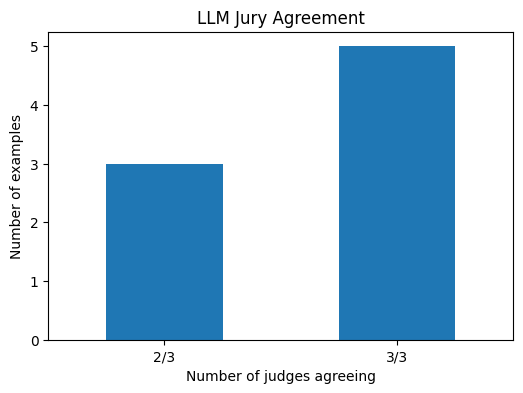

In [11]:
plt.figure(figsize=(6, 4))

jury_stats.plot(kind="bar")

plt.title("LLM Jury Agreement")
plt.xlabel("Number of judges agreeing")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)

plt.show()

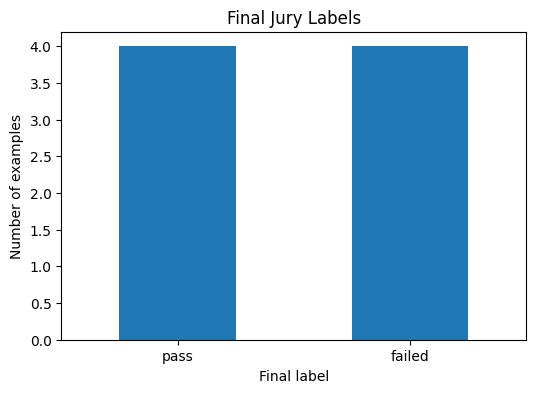

In [12]:
final_labels = df["jury_label"].value_counts()

plt.figure(figsize=(6, 4))

final_labels.plot(kind="bar")

plt.title("Final Jury Labels")
plt.xlabel("Final label")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)

plt.show()

## 9. Disagreement cases

Split decisions are often the most interesting examples.

They usually indicate ambiguous tone, unclear rubric boundaries, or subjective interpretation differences between judges.

In [13]:
split_cases = df[df["jury_agreement"] != "3/3"]

split_cases[[
    "customer_query",
    "assistant_answer",
    "gpt_5_5_label",
    "gpt_4_1_label",
    "gpt_4o_label",
    "jury_label",
]]

,customer_query,assistant_answer,gpt_5_5_label,gpt_4_1_label,gpt_4o_label,jury_label
2,Can I cancel my subscription?,You can usually cancel your subscription from ...,pass,failed,failed,failed
3,Why was my payment declined?,Your payment may have been declined by your ba...,pass,pass,failed,pass
7,Do you offer refunds?,Refund eligibility depends on the store policy...,pass,pass,failed,pass


## 10. Final note

Tone evaluation is subjective, and single LLM judges may be inconsistent.

Using multiple judges and majority voting can make evaluations more stable and robust.

Disagreement cases are especially useful because they reveal ambiguous examples and help refine the evaluation rubric.